### Data Exploration — NCT-CRC-HE-100K / CRC-VAL-HE-7K

Before any modeling happens, lets start understanding the data itself: what's actually in it, how it's structured, and whether it's clean enough to build on.

Seeing is believing. 

Steps covered here:

1. **Extract and load**: The training set (NCT-CRC-HE-100K) and the external validation set (CRC-VAL-HE-7K), kept separate from the start. Unzipping directly from the extracted data. External set stays untouched beyond basic structural checks until final evaluation.
2. **Inspect a sample image** to confirm the data loads correctly and check its basic properties (dimensions, pixel scale, format).
3. **Count patches per tissue class** to check for class imbalance before it becomes a modeling problem later.
4. **Visualize sample patches across all nine tissue classes**, to get a feel for what each class actually looks like and spot obvious staining variation early.
5. **Compute basic image statistics** (dimensions, per-channel color distributions) as a quantitative baseline — useful later for showing what stain normalization actually changes, rather than just asserting it helps.


In [1]:
from pathlib import Path
import numpy as np

from src.utilities.data_io import (
    extract_zip,
    count_patches_per_class,
    summarize_metadata_by_class,
    print_class_metadata_summary,
    export_sample_subset,
    compute_channel_stats
)
from src.utilities.viz import (
    plot_class_counts,
    plot_class_sample_grid,
    load_class_samples,
    plot_interactive_class_grid,
    plot_channel_stats,
    compute_cross_cohort_color_shift,
    plot_color_shift
)

In [2]:
# Get the path to the zip file zippaths can be changed to extract different datasets
zip_path_NCT= Path("data/NCT-CRC-HE-100K.zip")
zip_path_CRC= Path("data/CRC-VAL-HE-7K.zip")
zip_path_NCT_NONORM= Path("data/NCT-CRC-HE-100K-NONORM.zip")

#Extract the zip file
extract_to = Path("data")
for zip_path in [zip_path_NCT, zip_path_NCT_NONORM, zip_path_CRC]:
    extract_zip(zip_path, extract_to)

Skipping NCT-CRC-HE-100K.zip, already extracted.
Skipping NCT-CRC-HE-100K-NONORM.zip, already extracted.
Skipping CRC-VAL-HE-7K.zip, already extracted.


## Documentation patient-cohort

Patch-level patient IDs aren't included in this release, so patient-overlap between the training and external sets can't be independently re-verified from the files themselves — this section documents the guarantee as stated by the dataset's creators, rather than a computed check.

Per the dataset description ([Kather, Halama & Marx, 2018](https://doi.org/10.5281/zenodo.1214456); summarized in [openmedlab/Awesome-Medical-Dataset](https://github.com/openmedlab/Awesome-Medical-Dataset/blob/main/resources/NCT-CRC-HE-100K.md)):

- **NCT-CRC-HE-100K** (training set): 100,000 non-overlapping H&E patches drawn from colorectal cancer and healthy tissue slides sourced from the NCT Biobank and the University Medical Center Mannheim pathology archive.
- **CRC-VAL-HE-7K** (external validation set): a separate collection of patches from an independent patient cohort, assembled specifically to have no patient overlap with the training set.
- Both sets share the same nine tissue-class taxonomy (adipose, background, debris, lymphocytes, mucus, smooth muscle, normal mucosa, stroma, tumor epithelium), all patches standardized to 224×224px at 0.5 microns per pixel, which is why they can be used together as a matched train/external-validation pair.


In [3]:
# This extracts data if not already extracted
NCTpath= Path("data/NCT-CRC-HE-100K/")
NCT_NONORMpath= Path("data/NCT-CRC-HE-100K-NONORM/")
CRCpath= Path("data/CRC-VAL-HE-7K/")
print(f"Number of images in the 100K dataset: {len(list(NCTpath.glob('**/*.tif')))}")
print(f"Number of images in the 100K-NONORM dataset: {len(list(NCT_NONORMpath.glob('**/*.tif')))}")
print(f"Number of images in the CRC 7K validation dataset: {len(list(CRCpath.glob('**/*.tif')))}")

Number of images in the 100K dataset: 100000
Number of images in the 100K-NONORM dataset: 100000
Number of images in the CRC 7K validation dataset: 7180


Lets take a first looks at the datasets: A bar plot of the class counts in the NCT-CRC-HE-100K dataset


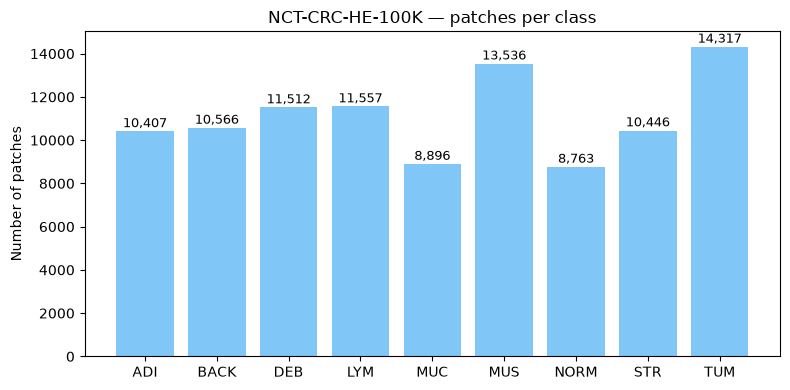

In [4]:
nct_counts = count_patches_per_class(NCT_NONORMpath)
print("Lets take a first looks at the datasets: A bar plot of the class counts in the NCT-CRC-HE-100K dataset")
plot_class_counts(nct_counts, title="NCT-CRC-HE-100K — patches per class")


In [5]:
# mild imbalance, ~1.6:1, not corrected for; per-class metrics report
counts_array = np.array(list(nct_counts.values()))
mean_count = counts_array.mean()

for class_name, count in nct_counts.items():
    pct_deviation = (abs(count - mean_count) / mean_count) * 100
    print(f"Class '{class_name}': {count} patches ({pct_deviation:.2f}% deviation from mean class size)")

Class 'ADI': 10407 patches (6.34% deviation from mean class size)
Class 'BACK': 10566 patches (4.91% deviation from mean class size)
Class 'DEB': 11512 patches (3.61% deviation from mean class size)
Class 'LYM': 11557 patches (4.01% deviation from mean class size)
Class 'MUC': 8896 patches (19.94% deviation from mean class size)
Class 'MUS': 13536 patches (21.82% deviation from mean class size)
Class 'NORM': 8763 patches (21.13% deviation from mean class size)
Class 'STR': 10446 patches (5.99% deviation from mean class size)
Class 'TUM': 14317 patches (28.85% deviation from mean class size)


### Class weights

As can be clearly seen from the graph and the deviations from mean class size the variations between classes dont pose a significant risk to training weights in this dataset. The largest deviation class "TUM" Colorectal adenocarcinoma epithelial is 1.6 times that of the least class "MUC" Mucus which doesnt warrant a rewieghting or particular preprocessing of data sample sizes before training. 

### Reading logic for bioio

While easy to use tiffile libraries are not always the best for reading large datasets. 

BioIO provides a more efficient way to read images as well as handling corresponding metadata. 

The following code demonstrates logic to read a single image using BioIO.

In [6]:
class_metadata = summarize_metadata_by_class(NCT_NONORMpath, n_samples=1)
print("Class image metadata summary:")
print_class_metadata_summary(class_metadata)

Class image metadata summary:
ADI    | n_files_sampled=1 | shape=(1, 1, 1, 224, 224, 3) | dim_order=TCZYXS | pixel_size =352.77777777777777, 352.77777777777777
BACK   | n_files_sampled=1 | shape=(1, 1, 1, 224, 224, 3) | dim_order=TCZYXS | pixel_size =352.77777777777777, 352.77777777777777
DEB    | n_files_sampled=1 | shape=(1, 1, 1, 224, 224, 3) | dim_order=TCZYXS | pixel_size =352.77777777777777, 352.77777777777777
LYM    | n_files_sampled=1 | shape=(1, 1, 1, 224, 224, 3) | dim_order=TCZYXS | pixel_size =352.77777777777777, 352.77777777777777
MUC    | n_files_sampled=1 | shape=(1, 1, 1, 224, 224, 3) | dim_order=TCZYXS | pixel_size =352.77777777777777, 352.77777777777777
MUS    | n_files_sampled=1 | shape=(1, 1, 1, 224, 224, 3) | dim_order=TCZYXS | pixel_size =352.77777777777777, 352.77777777777777
NORM   | n_files_sampled=1 | shape=(1, 1, 1, 224, 224, 3) | dim_order=TCZYXS | pixel_size =352.77777777777777, 352.77777777777777
STR    | n_files_sampled=1 | shape=(1, 1, 1, 224, 224, 3) | 

### Vizualize the dataset statically

Using a simple matplotlib grid we can already see the dramatic changes in color values between the different samples and 4 randomly picked images from each sample class. Done mainly for the README. Use the interactive plotly plot to vizualize samples directly. 


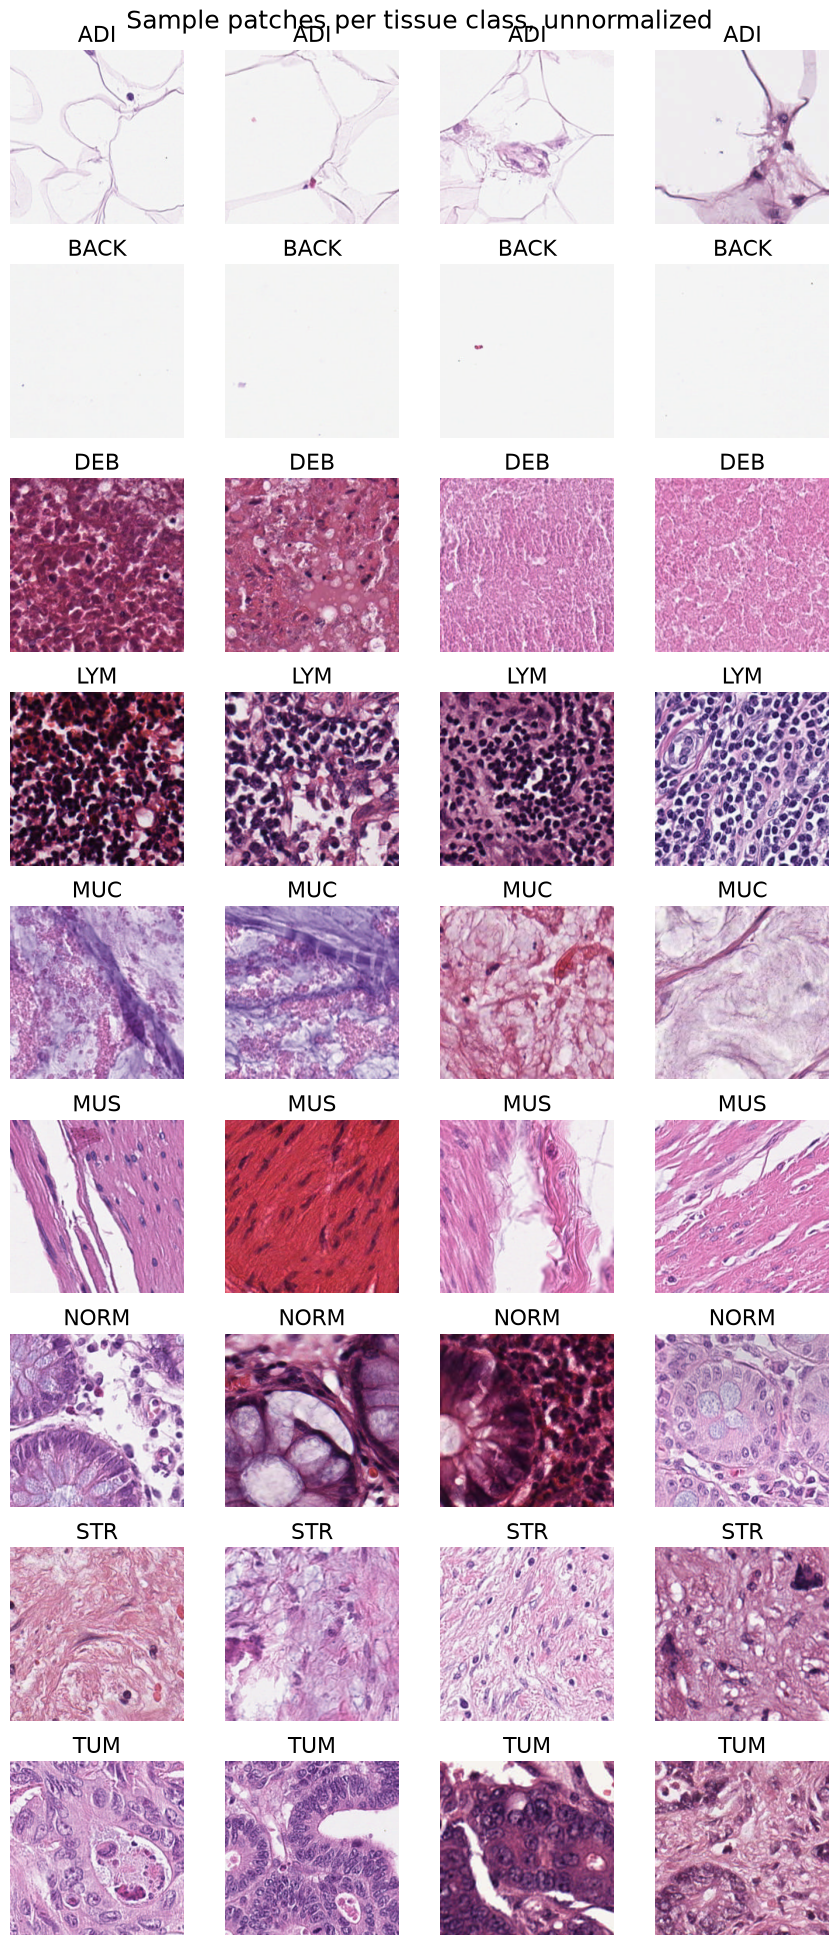

In [7]:
plot_class_sample_grid(NCT_NONORMpath, n_samples=4)

### Vizualize using plotly interactively


In [8]:
samples = load_class_samples(NCT_NONORMpath, n_samples=3)
fig = plot_interactive_class_grid(samples, n_samples=3)
fig.show()

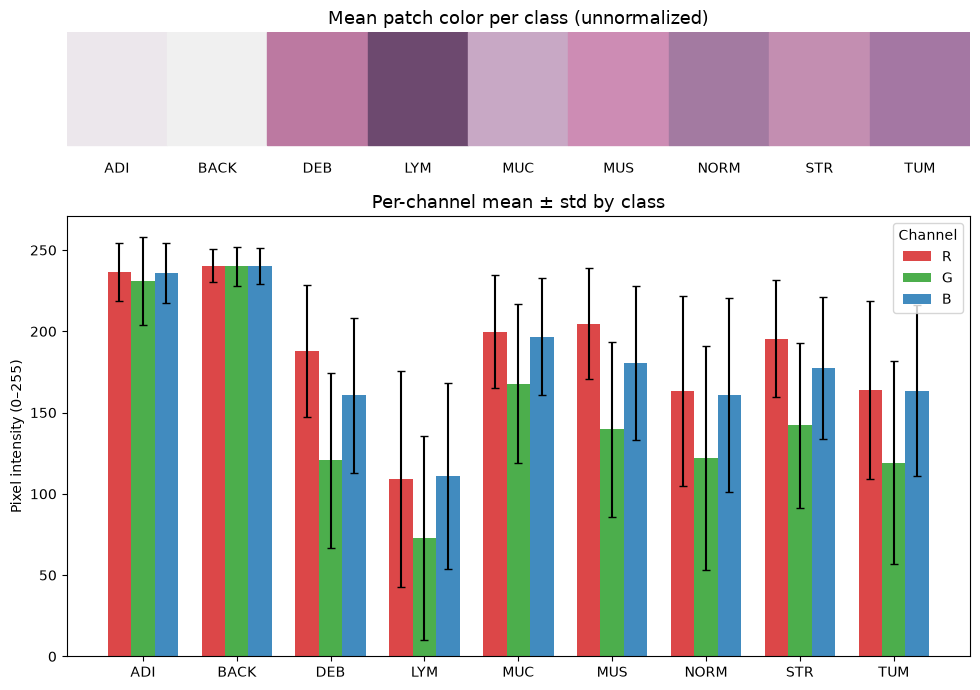

In [12]:
channel_stats=compute_channel_stats(NCT_NONORMpath, n_samples_per_class=400)
plot_channel_stats(channel_stats)

CRC-VAL-HE-7K — patches per class:


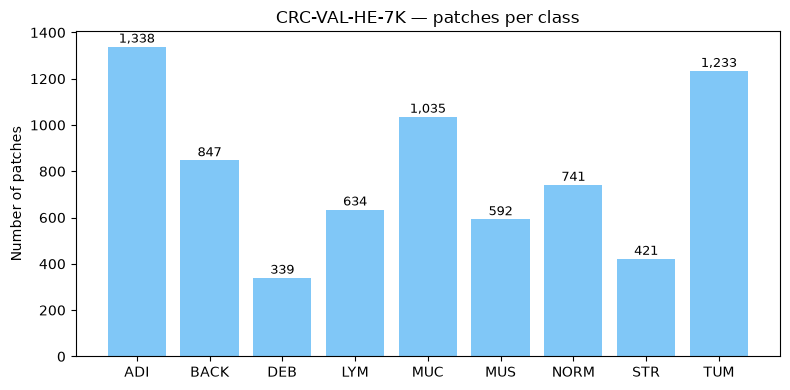

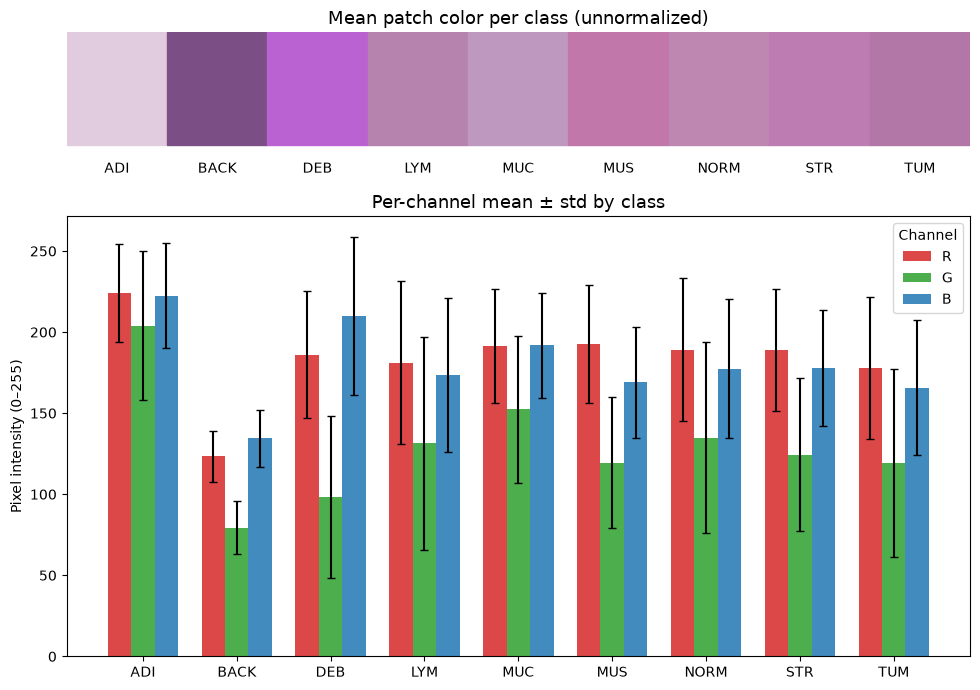

In [9]:
# CRC-VAL-HE-7K — structural check (external validation cohort)
crc_counts = count_patches_per_class(CRCpath)
print("CRC-VAL-HE-7K — patches per class:")
plot_class_counts(crc_counts, title="CRC-VAL-HE-7K — patches per class")

crc_channel_stats = compute_channel_stats(CRCpath)
plot_channel_stats(crc_channel_stats)
assert set(crc_counts.keys()) == set(nct_counts.keys()), "Class mismatch between train and external cohort!"

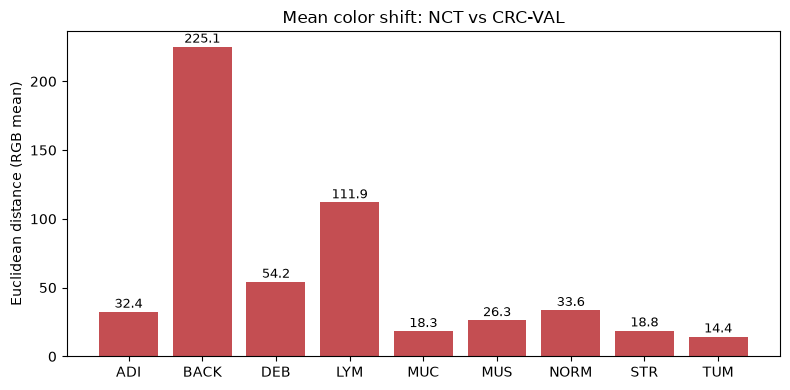

In [13]:
shifts = compute_cross_cohort_color_shift(channel_stats, crc_channel_stats)
plot_color_shift(shifts)

## Summary 


### **Data:** 
NCT-CRC-HE-100K (100,000 patches, training) and CRC-VAL-HE-7K (7,180 patches, external validation), both spanning the same nine-class colorectal histology taxonomy. 

Patient data and zendono support done by Kather et al. [doi](https://doi.org/10.5281/zenodo.1214456) with a readme available for the dataset [here](https://github.com/openmedlab/Awesome-Medical-Dataset/blob/main/resources/NCT-CRC-HE-100K.md). 

**Class balance:** Mild in the training set (~1.6:1, TUM to MUC) — not corrected for. More pronounced in the external validation set (~4:1, ADI to DEB), which reinforces the same decision from a second angle: results are reported per-class, not as a single aggregate accuracy, so no class's performance can hide behind another's.

**Staining variation:** Visible at three levels — within a single class (the sample grid shows real color spread even among patches of the same tissue type), and between cohorts (mean patch color per class differs measurably between NCT and CRC-VAL, most visibly in DEB, MUS, and NORM). BACK is the one class that's consistently near-white and low-variance across both datasets, as expected for background/no-tissue patches — not itself evidence of a staining problem.

**What this sets up for Notebook 02:** the per-class color-shift figures computed here are the "before" baseline. Macenko normalization should measurably reduce that cross-cohort shift, and the same functions built here (`compute_channel_stats`, `compute_cross_cohort_color_shift`) will be re-run on normalized data to show the actual before/after difference, rather than relying on a visual "looks better" impression.
